## **Bài thực hành bài 12**: Ứng dụng mô hình sequence2sequence cho bài toán dịch máy (machine translation)

Tổng quan: Ở bài tập này chúng ta sẽ lần lượt thực hành các bước để xây dựng một hệ thống học máy cho bài toán dịch máy dựa vào mạng seq2seq: tải và tiền xử lý dữ liệu song ngữ, tạo dữ liệu huấn luyện, xây dựng mô hình seq2seq với attention, hiển thị dữ liệu attention và dịch câu mới trên dữ liệu thực tế. Bài tập yêu cầu các kiến thức về lập trình Python với các thư viện: keras, numpy.

**1. Tải và tiền xử lý dữ liệu**

Nội dung chính: 
1.   Tải dữ liệu song ngữ
2.   Xóa các kí tự đặc biệt trong câu
3.   Tách từ (word tokenizer)
4.   Tạo từ điển
5.   Thêm các token đặc biệt vào câu như : start, end, pad





- Import các thư viện cần thiết

In [1]:
import tensorflow as tf

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split

import unicodedata
import re
import numpy as np
import os
import io
import time

I0000 00:00:1777880390.632329   35376 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777880392.672429   35376 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777880397.582307   35376 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


- Dowload dataset

Trong bài thực hành này chúng ra sẽ sử dụng bộ song ngữ Vietnamese - English gồm 133k cặp câu song ngữ

In [2]:
from pathlib import Path
import urllib.request
import tarfile
import shutil

OUT_DIR = Path("data_iwslt15")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: xoá folder "-p" bị Windows tạo nhầm từ lần chạy trước
shutil.rmtree("-p", ignore_errors=True)

MIRROR = "https://raw.githubusercontent.com/stefan-it/nmt-en-vi/master/data"

archives = {
    "train-en-vi.tgz": "training dataset train.en and train.vi",
    "dev-2012-en-vi.tgz": "dev dataset tst2012.en and tst2012.vi",
    "test-2013-en-vi.tgz": "test dataset tst2013.en and tst2013.vi",
}

for filename, description in archives.items():
    print(f"Download {description}.")
    url = f"{MIRROR}/{filename}"
    archive_path = OUT_DIR / filename

    urllib.request.urlretrieve(url, archive_path)

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(OUT_DIR)

    archive_path.unlink()

print("Verify files:")
for name in [
    "train.en", "train.vi",
    "tst2012.en", "tst2012.vi",
    "tst2013.en", "tst2013.vi",
]:
    path = OUT_DIR / name
    with open(path, "r", encoding="utf-8") as f:
        n_lines = sum(1 for _ in f)
    print(f"{path}: {n_lines:,} lines")

Download training dataset train.en and train.vi.
Download dev dataset tst2012.en and tst2012.vi.
Download test dataset tst2013.en and tst2013.vi.
Verify files:
data_iwslt15/train.en: 133,317 lines
data_iwslt15/train.vi: 133,317 lines
data_iwslt15/tst2012.en: 1,553 lines
data_iwslt15/tst2012.vi: 1,553 lines
data_iwslt15/tst2013.en: 1,268 lines
data_iwslt15/tst2013.vi: 1,268 lines


- Viết hàm tiền xử lý dữ liệu. Hàm này xử lý dữ liệu đầu vào như xóa bỏ các kí tự đặc biệt, lowercase, ... Ngoài ra ta cũng thêm token bắt đầu và kết thúc câu.

In [3]:
def preprocess_sentence(sentence):
  sentence = "<start> "+sentence+" <end>"
  return sentence


- Load data và xem thử data

In [9]:
def load_data(source_file, target_file, number_of_examples):
  # source_data = [preprocess_sentence(source_sentence) 
  #                 for source_sentence in open(source_file, "r").readlines()[:number_of_examples]]
  # target_data = [preprocess_sentence(target_sentence) 
  #                 for target_sentence in open(target_file, "r").readlines()[:number_of_examples]]
  max_len = 50
  source_sents = open(source_file, "r").readlines()
  target_sents = open(target_file, "r").readlines()
  assert len(source_sents) == len(target_sents)

  source_data, target_data = [], []
  for source_sentence, target_sentence in zip(source_sents[:number_of_examples],
                                              target_sents[:number_of_examples]):
    if len(source_sentence.strip().split()) > max_len or len(target_sentence.strip().split()) > max_len:
      continue
    source_data.append(preprocess_sentence(source_sentence))
    target_data.append(preprocess_sentence(target_sentence))
  
  return source_data, target_data
print(OUT_DIR)
train_src, train_trg = load_data(OUT_DIR / "train.en", OUT_DIR / "train.vi", 1000)
print(len(train_src), len(train_trg))
print(train_src[10])
print(train_trg[10])


data_iwslt15
929 929
<start> And every one of those scientists is in a research group , and every research group studies a wide variety of topics .
 <end>
<start> Mỗi một khoa học gia đều thuộc một nhóm nghiên cứu , và mỗi nhóm đều nghiên cứu rất nhiều đề tài đa dạng .
 <end>


- Viết hàm tách từ (tokenizer). Nhiều ngôn ngữ có thể phân tách các từ bằng dấu cách (space) như tiếng Anh, tiếng Việt, ... Nhưng 1 số ngôn ngữ không có dấu phân tách giữa các từ như tiếng Nhật, tiếng Trung Quốc. Vì vậy, ta cần có tách từ để phân tách các từ trong câu.

In [5]:
def tokenizer(sentences):
  tokenizer = tf.keras.preprocessing.text.Tokenizer(
      filters='')
  tokenizer.fit_on_texts(sentences)

  sent_tensors = tokenizer.texts_to_sequences(sentences)


  sent_tensors = tf.keras.preprocessing.sequence.pad_sequences(sent_tensors,
                                                         padding='post')
  
  return sent_tensors, tokenizer

def create_data(source_path, target_path, number_of_examples):
  # creating cleaned input, output pairs
  source_data, target_data = load_data(source_path, target_path, number_of_examples)
  source_tensors, source_tokenizer = tokenizer(source_data)
  target_tensors, target_tokenizer = tokenizer(target_data)

  return source_tensors, target_tensors, source_tokenizer, target_tokenizer



- Giới hạn số dữ liệu huấn luyện. Để kiểm tra xem chương trình chạy có đúng hay không, ban đầu ta có thể chạy thử với lượng nhỏ dữ liệu

In [6]:
number_of_examples = 50000
train_src_tensors, train_tgt_tensors, train_src_tokenizer, train_tgt_tokenizer = create_data(OUT_DIR / "train.en", OUT_DIR / "train.vi", number_of_examples)
valid_src_tensors, valid_tgt_tensors, _, _ = create_data(OUT_DIR / "tst2012.en", OUT_DIR / "tst2012.vi", -1)
test_src_tensors, test_tgt_tensors, _, _ = create_data(OUT_DIR / "tst2013.en", OUT_DIR / "tst2013.vi", -1)

max_length_source, max_length_target = train_src_tensors.shape[1], train_tgt_tensors.shape[1]

print(len(train_src_tensors))
# print(train_src_tensors[0])

# View source dictionary
print(len(train_src_tokenizer.word_index))
for t in train_src_tensors[0][:5]:
  print(t, train_src_tokenizer.index_word[t])


45952
26370
1 <start>
7615 rachel
14913 pike
56 :
5 the


**2. Tạo dữ liệu huấn luyện**

Nội dung chính: Tạo dữ liệu huấn luyện theo batch

In [7]:
BUFFER_SIZE = len(train_src_tensors)
BATCH_SIZE = 64
steps_per_epoch = len(train_src_tensors)//BATCH_SIZE

vocab_src_size = len(train_src_tokenizer.word_index)+1
vocab_tgt_size = len(train_tgt_tokenizer.word_index)+1

# YOUR CODE HERE
train_dataset = None
train_dataset = None
# YOUR CODE HERE


example_input_batch, example_target_batch = next(iter(train_dataset))
example_input_batch.shape, example_target_batch.shape

(TensorShape([64, 52]), TensorShape([64, 52]))

**3. Viết mô hình seq2seq với attention**

Nội dung chính : Viết Encoder, BahdanauAttention, Decoder

In [8]:
class Encoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, hidden_state_size, batch_sz):
    super(Encoder, self).__init__()
    # YOUR CODE HERE
    self.batch_sz = None
    self.hidden_state_size = None
    self.embedding = None
    self.gru = None


    # YOUR CODE HERE

  def call(self, x, hidden):
    # YOUR CODE HERE
    x = None
    output, state = None
    # YOUR CODE HERE
    return output, state

  def initialize_hidden_state(self):
    return tf.zeros((self.batch_sz, self.hidden_state_size))

- Tạo Encoder và test thử  Encoder đó với 1 batch dữ liệu và in ra shape của encoder output

In [9]:
embedding_dim = 512
hidden_state_size = 512


encoder = Encoder(vocab_src_size, embedding_dim, hidden_state_size, BATCH_SIZE)


# sample input
sample_hidden = encoder.initialize_hidden_state()
sample_output, sample_hidden = encoder(example_input_batch, sample_hidden)
print ('Encoder output shape: (batch size, sequence length, units) {}'.format(sample_output.shape))
print ('Encoder Hidden state shape: (batch size, units) {}'.format(sample_hidden.shape))
#

Encoder output shape: (batch size, sequence length, units) (64, 52, 512)
Encoder Hidden state shape: (batch size, units) (64, 512)


In [10]:
class BahdanauAttention(tf.keras.layers.Layer):
  def __init__(self, units):
    super(BahdanauAttention, self).__init__()
    self.W1 = tf.keras.layers.Dense(units)
    self.W2 = tf.keras.layers.Dense(units)
    self.V = tf.keras.layers.Dense(1)

  def call(self, query, values):
    # query hidden state shape == (batch_size, hidden size)
    # query_with_time_axis shape == (batch_size, 1, hidden size)
    # values shape == (batch_size, max_len, hidden size)
    # we are doing this to broadcast addition along the time axis to calculate the score
    query_with_time_axis = tf.expand_dims(query, 1)

    # score shape == (batch_size, max_length, 1)
    # we get 1 at the last axis because we are applying score to self.V
    # the shape of the tensor before applying self.V is (batch_size, max_length, units)
    score = self.V(tf.nn.tanh(
        self.W1(query_with_time_axis) + self.W2(values)))

    # attention_weights shape == (batch_size, max_length, 1)
    attention_weights = tf.nn.softmax(score, axis=1)

    # context_vector shape after sum == (batch_size, hidden_size)
    context_vector = attention_weights * values
    context_vector = tf.reduce_sum(context_vector, axis=1)

    return context_vector, attention_weights

In [11]:
attention_layer = BahdanauAttention(10)
attention_result, attention_weights = attention_layer(sample_hidden, sample_output)

print("Attention result shape: (batch size, units) {}".format(attention_result.shape))
print("Attention weights shape: (batch_size, sequence_length, 1) {}".format(attention_weights.shape))

Attention result shape: (batch size, units) (64, 512)
Attention weights shape: (batch_size, sequence_length, 1) (64, 52, 1)


In [12]:
class Decoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, hidden_state_size, batch_sz):
    super(Decoder, self).__init__()
    # YOUR CODE HERE
    self.batch_sz = None
    self.hidden_state_size = None
    self.embedding = None
    self.gru =  None


    self.fc = None
    # YOUR CODE HERE

    # used for attention
    self.attention = BahdanauAttention(self.hidden_state_size)

  def call(self, x, hidden, enc_output):
    # enc_output shape == (batch_size, max_length, hidden_size)
    context_vector, attention_weights = self.attention(hidden, enc_output)

    # x shape after passing through embedding == (batch_size, 1, embedding_dim)
    x = self.embedding(x)

    # x shape after concatenation == (batch_size, 1, embedding_dim + hidden_size)
    x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

    # passing the concatenated vector to the GRU
    output, state = self.gru(x)

    # output shape == (batch_size * 1, hidden_size)
    output = tf.reshape(output, (-1, output.shape[2]))

    # output shape == (batch_size, vocab)
    x = self.fc(output)

    return x, state, attention_weights

In [13]:
decoder = Decoder(vocab_tgt_size, embedding_dim, hidden_state_size, BATCH_SIZE)

sample_decoder_output, _, _ = decoder(tf.random.uniform((BATCH_SIZE, 1)),
                                      sample_hidden, sample_output)

print ('Decoder output shape: (batch_size, vocab size) {}'.format(sample_decoder_output.shape))

Decoder output shape: (batch_size, vocab size) (64, 12469)


**4. Định nghĩa hàm tối ưu (optimizer) và hàm lỗi (loss function)**

Nội dung chính: Sử dụng hàm tối ưu Adam và hàm lỗi CrossEntropy

In [14]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
  # YOUR CODE HERE
  mask = None)
  loss_ = None

  mask =None
  loss_ *= None
  # YOUR CODE HERE

  return tf.reduce_mean(loss_)

**5. Huấn luyện mô hình (Training)**

Nội dung chính: Sử dụng dữ liệu, mô hình seq2seq + attention đã build ở trên để huấn luyện mô hình.

In [15]:
@tf.function
def train_step(source, target, enc_hidden):
  loss = 0
  # YOUR CODE HERE
  with tf.GradientTape() as tape:
    enc_output, enc_hidden = None

    dec_hidden = None

    dec_input = None

    # Teacher forcing - feeding the target as the next input
    for t in range(1, target.shape[1]):
      # passing enc_output to the decoder
      predictions, dec_hidden, _ = None

      loss += None

      # using teacher forcing
      dec_input = None
  # YOUR CODE HERE


  batch_loss = (loss / int(target.shape[1]))

  variables = encoder.trainable_variables + decoder.trainable_variables

  gradients = tape.gradient(loss, variables)

  optimizer.apply_gradients(zip(gradients, variables))

  return batch_loss


checkpoint_dir = './model_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(optimizer=optimizer,
                                 encoder=encoder,
                                 decoder=decoder)

EPOCHS = 1

for epoch in range(EPOCHS):
  start = time.time()

  enc_hidden = encoder.initialize_hidden_state()
  total_loss = 0

  for (batch, (source, target)) in enumerate(train_dataset.take(steps_per_epoch)):
    batch_loss = train_step(source, target, enc_hidden)
    total_loss += batch_loss

    if batch % 100 == 0:
      print('Epoch {} Batch {} Loss {:.4f}'.format(epoch + 1,
                                                   batch,
                                                   batch_loss.numpy()))
  # saving (checkpoint) the model every 1 epochs
  checkpoint.save(file_prefix = checkpoint_prefix)

  print('Epoch {} Loss {:.4f}'.format(epoch + 1,
                                      total_loss / steps_per_epoch))
  print('Time taken for 1 epoch {} sec\n'.format(time.time() - start))




Epoch 1 Batch 0 Loss 3.5254
Epoch 1 Batch 100 Loss 2.6040
Epoch 1 Batch 200 Loss 2.6437
Epoch 1 Batch 300 Loss 2.3136
Epoch 1 Batch 400 Loss 2.2659
Epoch 1 Batch 500 Loss 2.3337
Epoch 1 Batch 600 Loss 2.2854
Epoch 1 Batch 700 Loss 2.0957
Epoch 1 Loss 2.3234
Time taken for 1 epoch 298.817334651947 sec



**6. Dịch (Translate)**

Nội dung chính: Sử dụng mô hình đã được huấn luyện để  dịch dữ liệu mới

In [16]:
def evaluate(source_sentence):
  attention_plot = np.zeros((max_length_target, max_length_source))

  source_sentence = preprocess_sentence(source_sentence)

  inputs = [train_src_tokenizer.word_index[i] for i in source_sentence.lower().split(' ')]
  inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs],
                                                         maxlen=max_length_source,
                                                         padding='post')
  inputs = tf.convert_to_tensor(inputs)

  result = ''

  # YOUR CODE HERE
  hidden = None
  enc_out, enc_hidden = None

  dec_hidden = None
  dec_input = None

  for t in range(max_length_target):
    predictions, dec_hidden, attention_weights = None

    # storing the attention weights to plot later on
    attention_weights = None
    attention_plot[t] = None

    predicted_id = None

    result += None

  # YOUR CODE HERE


    if train_tgt_tokenizer.index_word[predicted_id] == '<end>':
      return result, source_sentence, attention_plot

    # the predicted ID is fed back into the model
    dec_input = tf.expand_dims([predicted_id], 0)

  return result, source_sentence, attention_plot

source_sentence = "How are you ?"
result, source_sentence, attention_plot = evaluate(source_sentence)
print('Input: %s' % (source_sentence))
print('Predicted translation: {}'.format(result))

Input: <start> How are you ? <end>
Predicted translation: chúng ta có thể làm thế giới .
 <end> 


**7. Hiển thị attention (Plot attention)**

Nội dung chính : Hiển thị attention để hiểu rõ hơn vai trò của attention trong mô hình seq2seq


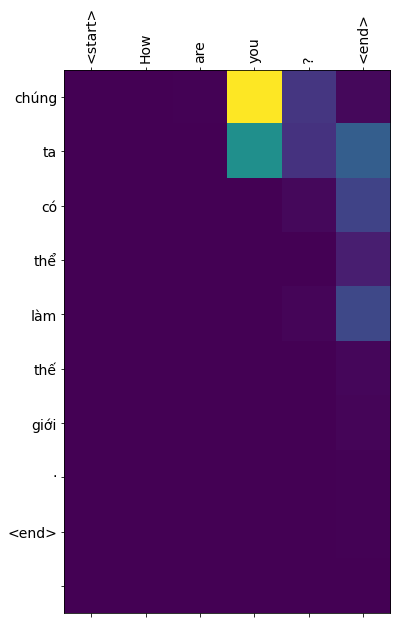

In [17]:
def plot_attention(attention, sentence, predicted_sentence):
  fig = plt.figure(figsize=(10,10))
  ax = fig.add_subplot(1, 1, 1)
  ax.matshow(attention, cmap='viridis')

  fontdict = {'fontsize': 14}

  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

  ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
  ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

  plt.show()

attention_plot = attention_plot[:len(result.split(' ')), :len(source_sentence.split(' '))]
plot_attention(attention_plot, source_sentence.split(' '), result.split(' '))

**8. Tính điểm BLEU**

BLEU là 1 độ đo rất phổ biến để đánh giá chất lượng của 1 hệ thống dịch máy. Bạn có thể download script tính multi-bleu tại github của mosesdecoder : https://github.com/moses-smt/mosesdecoder/blob/master/scripts/generic/multi-bleu.perl

Trong bài này, chúng tôi sẽ sử dụng hàm tính bleu có sẵn trong python.

In [18]:
from nltk.translate.bleu_score import sentence_bleu
reference = [['this', 'is', 'a', 'test']]
candidate = ['this', 'is', 'a', 'test']
score = sentence_bleu(reference, candidate)
print(score)

1.0


Bài tập : Hãy sử dụng BLEU để đánh giá mô hình bạn vừa huấn luyện